In [9]:
import pandas as pd
import numpy as np

# A theoretical domain-weight matrix assigning the literature-based impact 
# of lifestyle variables on specific disease risks (Scale: -1.0 to 1.0)
domain_weights = {
    'Variable': ['BMI_RANGE', 'DAILY_STEPS', 'DAILY_STRESS', 'SLEEP_HOURS', 'FRUITS_VEGGIES'],
    'Obesity_Risk': [1.0, -0.8, 0.3, -0.4, -0.5],
    'Mental_Health_Risk': [0.2, -0.4, 0.9, -0.7, -0.2],
    'CVD_Risk': [0.8, -0.9, 0.6, -0.3, -0.4]
}

knowledge_map = pd.DataFrame(domain_weights).set_index('Variable')
print("Domain Knowledge Map (Feature -> Disease Risk):\n")
print(knowledge_map)

Domain Knowledge Map (Feature -> Disease Risk):

                Obesity_Risk  Mental_Health_Risk  CVD_Risk
Variable                                                  
BMI_RANGE                1.0                 0.2       0.8
DAILY_STEPS             -0.8                -0.4      -0.9
DAILY_STRESS             0.3                 0.9       0.6
SLEEP_HOURS             -0.4                -0.7      -0.3
FRUITS_VEGGIES          -0.5                -0.2      -0.4


In [10]:
df = pd.read_csv("Wellbeing_and_lifestyle_data_Kaggle (Sharanjit ma'am assigned).csv")
df


,Timestamp,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,...,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,07-07-2015,3,2,2,5,0,5,2,0,1,...,7,5,5,1,4,0,5,36 to 50,Female,609.5
1,07-07-2015,2,3,4,3,8,10,5,2,2,...,8,2,2,2,3,2,6,36 to 50,Female,655.6
2,07-07-2015,2,3,3,4,4,10,3,2,2,...,8,10,2,2,4,8,3,36 to 50,Female,631.6
3,07-07-2015,3,3,10,3,10,7,2,5,2,...,5,7,5,1,5,2,0,51 or more,Female,622.7
4,07-07-2015,5,1,3,3,10,4,2,4,2,...,7,0,0,2,8,1,5,51 or more,Female,663.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15967,3/14/21 5:42,3,3,0,4,0,10,0,4,2,...,7,0,1,1,5,2,5,51 or more,Female,644.5
15968,3/14/21 6:30,3,3,6,8,7,4,6,3,1,...,6,0,0,2,10,5,8,21 to 35,Female,714.9
15969,3/14/21 8:35,4,3,0,10,10,8,6,5,1,...,7,0,1,2,10,1,10,21 to 35,Male,716.6
15970,3/14/21 8:43,1,1,10,8,2,7,3,2,1,...,8,7,2,2,1,6,8,21 to 35,Female,682.0


In [11]:
df.drop(columns=['Timestamp'], inplace=True)  # Remove ID for modeling
print("\nDataset after dropping 'timestamp':\n")
df.head()


Dataset after dropping 'timestamp':



,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,...,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,3,2,2,5,0,5,2,0,1,6,...,7,5,5,1,4,0,5,36 to 50,Female,609.5
1,2,3,4,3,8,10,5,2,2,5,...,8,2,2,2,3,2,6,36 to 50,Female,655.6
2,2,3,3,4,4,10,3,2,2,2,...,8,10,2,2,4,8,3,36 to 50,Female,631.6
3,3,3,10,3,10,7,2,5,2,3,...,5,7,5,1,5,2,0,51 or more,Female,622.7
4,5,1,3,3,10,4,2,4,2,5,...,7,0,0,2,8,1,5,51 or more,Female,663.9


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15972 entries, 0 to 15971
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15972 non-null  int64  
 1   DAILY_STRESS             15972 non-null  str    
 2   PLACES_VISITED           15972 non-null  int64  
 3   CORE_CIRCLE              15972 non-null  int64  
 4   SUPPORTING_OTHERS        15972 non-null  int64  
 5   SOCIAL_NETWORK           15972 non-null  int64  
 6   ACHIEVEMENT              15972 non-null  int64  
 7   DONATION                 15972 non-null  int64  
 8   BMI_RANGE                15972 non-null  int64  
 9   TODO_COMPLETED           15972 non-null  int64  
 10  FLOW                     15972 non-null  int64  
 11  DAILY_STEPS              15972 non-null  int64  
 12  LIVE_VISION              15972 non-null  int64  
 13  SLEEP_HOURS              15972 non-null  int64  
 14  LOST_VACATION            15972 no

In [13]:
df.describe()

,FRUITS_VEGGIES,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,FLOW,DAILY_STEPS,LIVE_VISION,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,WORK_LIFE_BALANCE_SCORE
count,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000
mean,2.922677,5.232970,5.508077,5.616454,6.474267,4.000751,2.715314,1.410656,5.745993,3.194778,5.703606,3.752129,7.042888,2.898886,2.930879,1.728963,5.711558,3.326572,6.233346,666.751503
std,1.442694,3.311912,2.840334,3.242021,3.086672,2.755837,1.851586,0.491968,2.624097,2.357518,2.891013,3.230987,1.199044,3.692180,2.676301,0.444509,3.089630,2.729293,3.016571,45.019868
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,480.000000
25%,2.000000,2.000000,3.000000,3.000000,4.000000,2.000000,1.000000,1.000000,4.000000,1.000000,3.000000,1.000000,6.000000,0.000000,1.000000,1.000000,3.000000,1.000000,4.000000,636.000000
50%,3.000000,5.000000,5.000000,5.000000,6.000000,3.000000,3.000000,1.000000,6.000000,3.000000,5.000000,3.000000,7.000000,0.000000,2.000000,2.000000,5.000000,3.000000,7.000000,667.700000
75%,4.000000,8.000000,8.000000,10.000000,10.000000,6.000000,5.000000,2.000000,8.000000,5.000000,8.000000,5.000000,8.000000,5.000000,4.000000,2.000000,9.000000,5.000000,10.000000,698.500000
max,5.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,10.000000,10.000000,10.000000,820.200000


In [14]:
for col in df.columns:
    print(f"The unique values in {col}: {df[col].unique()}\n")

The unique values in FRUITS_VEGGIES: [3 2 5 4 1 0]

The unique values in DAILY_STRESS: <StringArray>
['2', '3', '1', '4', '5', '0', '01-01-2000']
Length: 7, dtype: str

The unique values in PLACES_VISITED: [ 2  4  3 10  5  6  7  0  8  1  9]

The unique values in CORE_CIRCLE: [ 5  3  4  9  6  7  8 10  2  1  0]

The unique values in SUPPORTING_OTHERS: [ 0  8  4 10  5  3  1  2  6  7  9]

The unique values in SOCIAL_NETWORK: [ 5 10  7  4  3  1  2  8  6  9  0]

The unique values in ACHIEVEMENT: [ 2  5  3  4  0  1  6 10  8  7  9]

The unique values in DONATION: [0 2 5 4 3 1]

The unique values in BMI_RANGE: [1 2]

The unique values in TODO_COMPLETED: [ 6  5  2  3  8 10  7  4  1  0  9]

The unique values in FLOW: [ 4  2  5  0  1  8  7  6  3 10  9]

The unique values in DAILY_STEPS: [ 5  4  7  8  1  3  6  2 10  9]

The unique values in LIVE_VISION: [ 0  5 10  4  2  1  6  3  8  9  7]

The unique values in SLEEP_HOURS: [ 7  8  5  6 10  9  4  3  2  1]

The unique values in LOST_VACATION: [ 5  2 1

In [15]:
#i want to drop a row in which the 'DAILY_STRESS' column has a specific value of 01-01-2000
df = df[df['DAILY_STRESS'] != '01-01-2000']
df['DAILY_STRESS'].unique()

<StringArray>
['2', '3', '1', '4', '5', '0']
Length: 6, dtype: str

In [16]:
df['GENDER'].unique()
df['GENDER_NEW'] = df['GENDER'].map({'Male': 0, 'Female': 1})
print(df['GENDER_NEW'].unique())

[1 0]


In [17]:
df.head()


,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,...,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE,GENDER_NEW
0,3,2,2,5,0,5,2,0,1,6,...,5,5,1,4,0,5,36 to 50,Female,609.5,1
1,2,3,4,3,8,10,5,2,2,5,...,2,2,2,3,2,6,36 to 50,Female,655.6,1
2,2,3,3,4,4,10,3,2,2,2,...,10,2,2,4,8,3,36 to 50,Female,631.6,1
3,3,3,10,3,10,7,2,5,2,3,...,7,5,1,5,2,0,51 or more,Female,622.7,1
4,5,1,3,3,10,4,2,4,2,5,...,0,0,2,8,1,5,51 or more,Female,663.9,1


In [18]:
df['AGE_GROUP']  = df['AGE'].map({ "Less than 20": 0, "21 to 35": 1, "36 to 50": 2, "51 or more": 3 })

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  str    
 2   PLACES_VISITED           15971 non-null  int64  
 3   CORE_CIRCLE              15971 non-null  int64  
 4   SUPPORTING_OTHERS        15971 non-null  int64  
 5   SOCIAL_NETWORK           15971 non-null  int64  
 6   ACHIEVEMENT              15971 non-null  int64  
 7   DONATION                 15971 non-null  int64  
 8   BMI_RANGE                15971 non-null  int64  
 9   TODO_COMPLETED           15971 non-null  int64  
 10  FLOW                     15971 non-null  int64  
 11  DAILY_STEPS              15971 non-null  int64  
 12  LIVE_VISION              15971 non-null  int64  
 13  SLEEP_HOURS              15971 non-null  int64  
 14  LOST_VACATION            15971 non-nul

In [20]:
df['DAILY_STRESS'] = df['DAILY_STRESS'].astype(int)

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  int64  
 2   PLACES_VISITED           15971 non-null  int64  
 3   CORE_CIRCLE              15971 non-null  int64  
 4   SUPPORTING_OTHERS        15971 non-null  int64  
 5   SOCIAL_NETWORK           15971 non-null  int64  
 6   ACHIEVEMENT              15971 non-null  int64  
 7   DONATION                 15971 non-null  int64  
 8   BMI_RANGE                15971 non-null  int64  
 9   TODO_COMPLETED           15971 non-null  int64  
 10  FLOW                     15971 non-null  int64  
 11  DAILY_STEPS              15971 non-null  int64  
 12  LIVE_VISION              15971 non-null  int64  
 13  SLEEP_HOURS              15971 non-null  int64  
 14  LOST_VACATION            15971 non-nul

In [22]:
df.drop(columns=['AGE', 'GENDER'], inplace=True)

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  int64  
 2   PLACES_VISITED           15971 non-null  int64  
 3   CORE_CIRCLE              15971 non-null  int64  
 4   SUPPORTING_OTHERS        15971 non-null  int64  
 5   SOCIAL_NETWORK           15971 non-null  int64  
 6   ACHIEVEMENT              15971 non-null  int64  
 7   DONATION                 15971 non-null  int64  
 8   BMI_RANGE                15971 non-null  int64  
 9   TODO_COMPLETED           15971 non-null  int64  
 10  FLOW                     15971 non-null  int64  
 11  DAILY_STEPS              15971 non-null  int64  
 12  LIVE_VISION              15971 non-null  int64  
 13  SLEEP_HOURS              15971 non-null  int64  
 14  LOST_VACATION            15971 non-nul

In [24]:
df.drop(columns=['PLACES_VISITED','LOST_VACATION','LIVE_VISION','DONATION','ACHIEVEMENT', 'PERSONAL_AWARDS'], inplace=True)

In [ ]:
pd.DataFrame(df).to_csv('Copy Dataset.csv', index=False)

In [26]:
for col in df.columns:
    print(f"The unique values in {col}: {df[col].unique()}\n")

The unique values in FRUITS_VEGGIES: [3 2 5 4 1 0]

The unique values in DAILY_STRESS: [2 3 1 4 5 0]

The unique values in CORE_CIRCLE: [ 5  3  4  9  6  7  8 10  2  1  0]

The unique values in SUPPORTING_OTHERS: [ 0  8  4 10  5  3  1  2  6  7  9]

The unique values in SOCIAL_NETWORK: [ 5 10  7  4  3  1  2  8  6  9  0]

The unique values in BMI_RANGE: [1 2]

The unique values in TODO_COMPLETED: [ 6  5  2  3  8 10  7  4  1  0  9]

The unique values in FLOW: [ 4  2  5  0  1  8  7  6  3 10  9]

The unique values in DAILY_STEPS: [ 5  4  7  8  1  3  6  2 10  9]

The unique values in SLEEP_HOURS: [ 7  8  5  6 10  9  4  3  2  1]

The unique values in DAILY_SHOUTING: [ 5  2  0  3  1  7  6  4 10  8  9]

The unique values in SUFFICIENT_INCOME: [1 2]

The unique values in TIME_FOR_PASSION: [ 0  2  8  1  3  6  5  4 10  9  7]

The unique values in WEEKLY_MEDITATION: [ 5  6  3  0 10  2  1  7  4  8  9]

The unique values in WORK_LIFE_BALANCE_SCORE: [609.5 655.6 631.6 ... 651.7 611.5 790.5]

The unique

In [38]:
X = df.drop(columns=['WORK_LIFE_BALANCE_SCORE'])
y = df['WORK_LIFE_BALANCE_SCORE']

In [39]:
# Importing standard scaler for normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
df_scaled


,FRUITS_VEGGIES,DAILY_STRESS,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,BMI_RANGE,TODO_COMPLETED,FLOW,DAILY_STEPS,SLEEP_HOURS,DAILY_SHOUTING,SUFFICIENT_INCOME,TIME_FOR_PASSION,WEEKLY_MEDITATION,GENDER_NEW,AGE_GROUP
0,0.053599,-0.578819,-0.178965,-1.732407,-0.477572,-0.834683,0.096804,0.341727,-0.243371,-0.035823,0.773095,-1.63991,-1.218845,-0.408970,0.787468,0.421337
1,-0.639548,0.152304,-0.883141,0.735331,1.142362,1.198059,-0.284280,-0.506733,-0.243371,0.798194,-0.347874,0.60979,-0.485987,-0.077447,0.787468,0.421337
2,-0.639548,0.152304,-0.531053,-0.498538,1.142362,1.198059,-1.427530,-0.506733,-0.589270,0.798194,-0.347874,0.60979,1.712587,-1.072015,0.787468,0.421337
3,0.053599,0.152304,-0.883141,1.352265,0.170402,1.198059,-1.046447,0.765957,-0.243371,-1.703858,0.773095,-1.63991,-0.485987,-2.066583,0.787468,1.480214
4,1.439895,-1.309943,-0.883141,1.352265,-0.801558,1.198059,-0.284280,-1.355194,-0.243371,-0.035823,-1.095186,0.60979,-0.852416,-0.408970,0.787468,1.480214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15966,0.053599,0.152304,-0.531053,-1.732407,1.142362,1.198059,0.858971,-0.506733,1.486128,-0.035823,-0.721530,-1.63991,-0.485987,-0.408970,0.787468,1.480214
15967,0.053599,0.152304,0.877299,0.426863,-0.801558,-0.834683,0.477887,0.765957,0.102529,-0.869841,-1.095186,0.60979,0.613300,0.585598,0.787468,-0.637541
15968,0.746747,0.152304,1.581476,1.352265,0.494389,-0.834683,0.477887,-0.082503,-0.243371,-0.035823,-0.721530,0.60979,-0.852416,1.248643,-1.269893,-0.637541
15969,-1.332696,-1.309943,0.877299,-1.115473,0.170402,-0.834683,0.096804,2.887108,-1.626970,0.798194,-0.347874,0.60979,0.979729,0.585598,0.787468,-0.637541


In [ ]:
import matplotlib.pyplot as plt

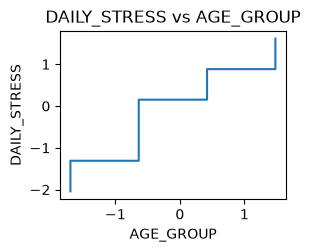

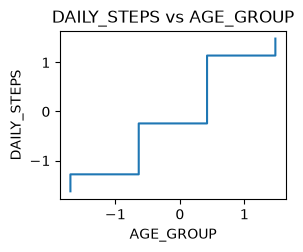

In [51]:
# making the subplots
plt.subplot(2, 2, 1)
plt.plot(df_scaled['AGE_GROUP'].sort_values(), df_scaled['DAILY_STRESS'].sort_values())
plt.title('DAILY_STRESS vs AGE_GROUP')
plt.xlabel('AGE_GROUP')
plt.ylabel('DAILY_STRESS')
plt.show()

plt.subplot(2, 2, 2)
plt.plot(df_scaled['AGE_GROUP'].sort_values(), df_scaled['DAILY_STEPS'].sort_values())
plt.title('DAILY_STEPS vs AGE_GROUP')
plt.xlabel('AGE_GROUP') 
plt.ylabel('DAILY_STEPS')
plt.show()

In [46]:
df_scaled.shape

(15971, 16)